## VGAE : deciphering spatial cellular communication through adaptive graph model on micoenvironment samples

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import traceback


from sklearn.metrics.pairwise import cosine_similarity

## Identify best epoch for each availabile Grid sample

In [2]:
best_epoch_by_grid = {
    1: 22,
    3: 17,
    5: 12,
    6: 17,
    9: 17,
    12: 12,
    14 : 26,
    16 : 16,
    18 : 21,
    20 : 18
}

In [3]:
def plot_vgae_embedding_heatmap(
    npy_file,
    meta_file,
    output_dir,
    celltype_col=None,
    meta_sep="\t",
    show_plot=False
):
    os.makedirs(output_dir, exist_ok=True)

    emb = np.load(npy_file)
    print("Embedding shape:", emb.shape)

    if emb.ndim != 2:
        raise ValueError(f"Embedding must be 2D. Got: {emb.shape}")

    meta = pd.read_csv(meta_file, sep=meta_sep, index_col=0)
    meta.index = meta.index.astype(str)

    if celltype_col is None:
        for cand in ["celltype", "cell_type", "type"]:
            if cand in meta.columns:
                celltype_col = cand
                break

    if celltype_col is None:
        raise ValueError("Could not find cell-type column.")

    if len(meta) != emb.shape[0]:
        raise ValueError(
            f"Mismatch: embedding has {emb.shape[0]} cells, "
            f"but meta has {len(meta)} rows."
        )

    sim = cosine_similarity(emb)

    cell_ids = meta.index.tolist()
    sim_df = pd.DataFrame(sim, index=cell_ids, columns=cell_ids)

    sim_csv = os.path.join(output_dir, "cell_cell_cosine_similarity.csv")
    sim_df.to_csv(sim_csv)

    df_long = sim_df.stack().reset_index()
    df_long.columns = ["cell_i", "cell_j", "cosine_score"]

    celltype_map = meta[celltype_col].astype(str).to_dict()

    df_long["type_i"] = df_long["cell_i"].map(celltype_map)
    df_long["type_j"] = df_long["cell_j"].map(celltype_map)

    type_sim = (
        df_long
        .groupby(["type_i", "type_j"])["cosine_score"]
        .mean()
        .unstack()
    )

    all_types = sorted(meta[celltype_col].astype(str).unique())
    type_sim = type_sim.reindex(index=all_types, columns=all_types)

    type_csv = os.path.join(output_dir, "celltype_cosine_similarity_mean.csv")
    type_sim.to_csv(type_csv)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        type_sim,
        cmap="viridis",
        linewidths=0.5,
        square=False,
        cbar_kws={"label": "Mean cosine similarity"}
    )

    plt.title("VGAE-CCI Cell-Type Cosine Similarity")
    plt.xlabel("Receiver cell type")
    plt.ylabel("Sender cell type")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    fig_path = os.path.join(output_dir, "celltype_cosine_heatmap.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close()

    print("Saved:", type_csv)
    print("Saved:", fig_path)

    return type_sim


In [4]:

base_dir = "/home/akram/share/Multiple_Grids/VGAE_CCI"

all_vgae_matrices = []
grid_metadata = []

for grid_id, best_epoch in best_epoch_by_grid.items():

    grid_dir = os.path.join(base_dir, f"Grid_{grid_id}")
    output_dir = os.path.join(grid_dir, "output")
    meta_file = os.path.join(grid_dir, f"Grid_{grid_id}_meta.csv")

    npy_file = os.path.join(
        output_dir,
        f"emb_hidden3_{best_epoch}.npy"
    )

    if not os.path.exists(npy_file):
        print("Missing:", npy_file)
        continue

    type_sim = plot_vgae_embedding_heatmap(
        npy_file=npy_file,
        meta_file=meta_file,
        output_dir=output_dir,
        celltype_col="cell_type",
        meta_sep="\t",
        show_plot=False
    )

    matrix_path = os.path.join(
        output_dir,
        f"VGAECCI_celltype_matrix_Grid_{grid_id}_epoch_{best_epoch}.csv"
    )

    type_sim.to_csv(matrix_path)

    all_vgae_matrices.append(type_sim)

    grid_metadata.append({
        "grid_id": grid_id,
        "best_epoch": best_epoch,
        "n_celltypes": type_sim.shape[0],
        "celltypes_present": ", ".join(type_sim.index.astype(str))
    })

grid_metadata_df = pd.DataFrame(grid_metadata)
display(grid_metadata_df)

Embedding shape: (2812, 125)
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/Grid_1/output/celltype_cosine_similarity_mean.csv
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/Grid_1/output/celltype_cosine_heatmap.png
Embedding shape: (3635, 125)
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/Grid_3/output/celltype_cosine_similarity_mean.csv
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/Grid_3/output/celltype_cosine_heatmap.png
Embedding shape: (1019, 125)
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/Grid_5/output/celltype_cosine_similarity_mean.csv
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/Grid_5/output/celltype_cosine_heatmap.png
Embedding shape: (534, 125)
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/Grid_6/output/celltype_cosine_similarity_mean.csv
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/Grid_6/output/celltype_cosine_heatmap.png
Embedding shape: (2454, 125)
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/Grid_9/output/celltype_cosine_similarity_mean.c

,grid_id,best_epoch,n_celltypes,celltypes_present
0,1,22,18,"Astrocyte, B cell, Endothelial, Ependymal, Mac..."
1,3,17,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
2,5,12,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
3,6,17,13,"Astrocyte, Endothelial, Macrophage, Microglia,..."
4,9,17,15,"Astrocyte, Endothelial, Ependymal, Macrophage,..."
5,12,12,14,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
6,14,26,13,"Astrocyte, Endothelial, Macrophage, Microglia,..."
7,16,16,16,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
8,18,21,14,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
9,20,18,14,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."


## Create one mean heatmap across all grids

In [5]:
summary_dir = os.path.join(base_dir, "summary_results")
os.makedirs(summary_dir, exist_ok=True)

if len(all_vgae_matrices) == 0:
    raise ValueError("No VGAE matrices were generated.")

all_celltypes = sorted(
    set().union(*[
        set(mat.index).union(set(mat.columns))
        for mat in all_vgae_matrices
    ])
)

aligned_matrices = []

for mat in all_vgae_matrices:
    mat_aligned = mat.reindex(
        index=all_celltypes,
        columns=all_celltypes,
        fill_value=0
    )
    aligned_matrices.append(mat_aligned)

matrix_stack = np.stack([
    mat.values for mat in aligned_matrices
])

mean_matrix = pd.DataFrame(
    matrix_stack.mean(axis=0),
    index=all_celltypes,
    columns=all_celltypes
)

std_matrix = pd.DataFrame(
    matrix_stack.std(axis=0),
    index=all_celltypes,
    columns=all_celltypes
)

cv_matrix = std_matrix / mean_matrix.replace(0, np.nan)

mean_path = os.path.join(summary_dir, "VGAECCI_MEAN_celltype_matrix_ALL_GRIDS.csv")
std_path = os.path.join(summary_dir, "VGAECCI_STD_celltype_matrix_ALL_GRIDS.csv")
cv_path = os.path.join(summary_dir, "VGAECCI_CV_celltype_matrix_ALL_GRIDS.csv")

mean_matrix.to_csv(mean_path)
std_matrix.to_csv(std_path)
cv_matrix.to_csv(cv_path)

print("Saved:", mean_path)
print("Saved:", std_path)
print("Saved:", cv_path)

Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/summary_results/VGAECCI_MEAN_celltype_matrix_ALL_GRIDS.csv
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/summary_results/VGAECCI_STD_celltype_matrix_ALL_GRIDS.csv
Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/summary_results/VGAECCI_CV_celltype_matrix_ALL_GRIDS.csv


## Plot mean VGAE-CCI heatmap

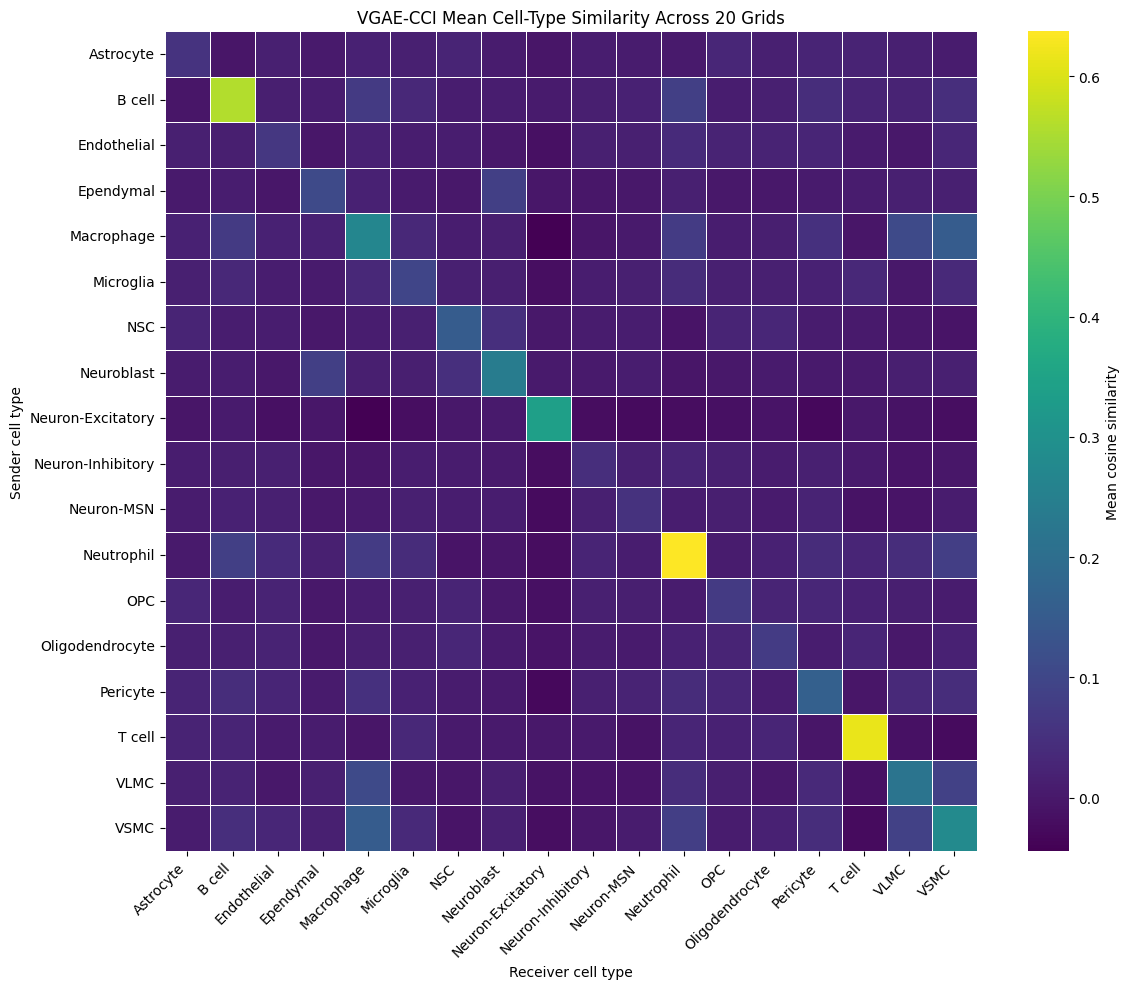

Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/summary_results/VGAECCI_MEAN_heatmap_ALL_GRIDS.png


In [6]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    mean_matrix,
    cmap="viridis",
    linewidths=0.5,
    square=False,
    cbar_kws={"label": "Mean cosine similarity"}
)

plt.title("VGAE-CCI Mean Cell-Type Similarity Across 20 Grids")
plt.xlabel("Receiver cell type")
plt.ylabel("Sender cell type")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

mean_heatmap_path = os.path.join(
    summary_dir,
    "VGAECCI_MEAN_heatmap_ALL_GRIDS.png"
)

plt.savefig(mean_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", mean_heatmap_path)

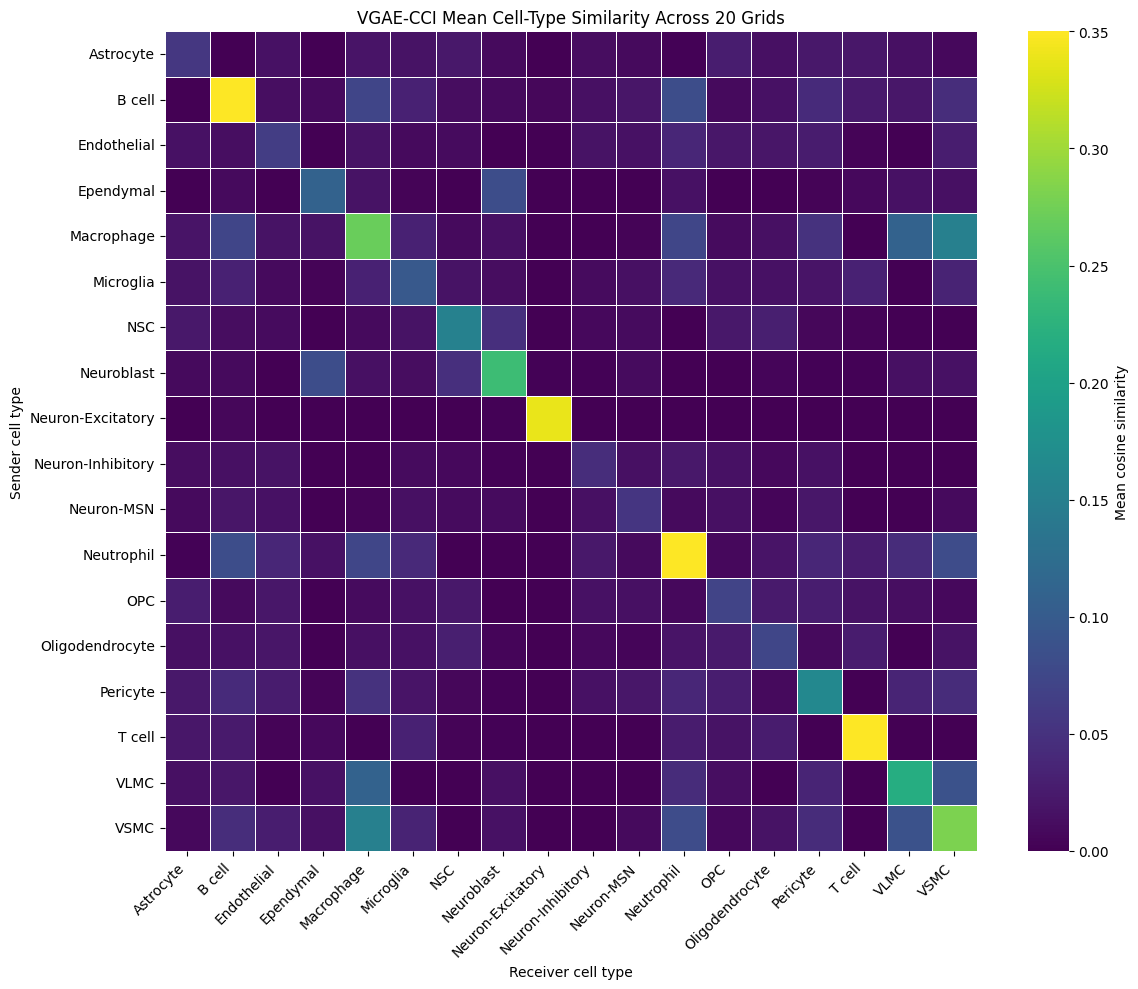

Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/summary_results/VGAECCI_MEAN_heatmap_ALL_GRIDS_scond_scale.png


In [11]:
# CHANGED: better color scaling
vmin = 0
vmax = 0.35   # adjust manually

plt.figure(figsize=(12, 10))

sns.heatmap(
    mean_matrix,
    cmap="viridis",
    linewidths=0.5,
    square=False,
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": "Mean cosine similarity"}
)

plt.title("VGAE-CCI Mean Cell-Type Similarity Across 20 Grids")
plt.xlabel("Receiver cell type")
plt.ylabel("Sender cell type")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

mean_heatmap_path = os.path.join(
    summary_dir,
    "VGAECCI_MEAN_heatmap_ALL_GRIDS_scond_scale.png"
)

plt.savefig(mean_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", mean_heatmap_path)

## Save grid metadata

In [106]:
grid_metadata_df = pd.DataFrame(grid_metadata)

grid_metadata_df = grid_metadata_df.sort_values(
    by="grid_id"
).reset_index(drop=True)

metadata_path = os.path.join(
    summary_dir,
    "VGAECCI_grid_metadata_summary.csv"
)

grid_metadata_df.to_csv(metadata_path, index=False)

display(grid_metadata_df)

print("Saved:", metadata_path)

,grid_id,best_epoch,n_celltypes,celltypes_present
0,1,22,18,"Astrocyte, B cell, Endothelial, Ependymal, Mac..."
1,3,17,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
2,5,12,15,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
3,6,17,13,"Astrocyte, Endothelial, Macrophage, Microglia,..."
4,9,17,15,"Astrocyte, Endothelial, Ependymal, Macrophage,..."
5,12,12,14,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
6,14,26,13,"Astrocyte, Endothelial, Macrophage, Microglia,..."
7,16,16,16,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
8,18,21,14,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."
9,20,18,14,"Astrocyte, B cell, Endothelial, Macrophage, Mi..."


Saved: /home/akram/share/Multiple_Grids/VGAE_CCI/summary_results/VGAECCI_grid_metadata_summary.csv
